### 1: Imports and Setup

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import keras_tuner as kt

keras.utils.set_random_seed(42)

### 2: Data Preprocessing

In [2]:
import sys
sys.path.append("..")
from project_paths import DATA_DIR

df5 = pd.read_parquet(DATA_DIR / "train_features_5m_clean.parquet")

# Train-test split
df5_date = pd.to_datetime(df5["bar5"]).dt.date
train_df= df5[df5_date < pd.Timestamp("2025-10-03").date()]
test_df = df5[df5_date >= pd.Timestamp("2025-10-06").date()]

In [4]:
# Extract and scale OHLC and option features into one combined input matrix
ohlc_cols = [f'm{i}_{c}' for i in range(1, 6) for c in ['open', 'high', 'low', 'close']]
FEATURES = ['prev_5m_log_return_1', 'prev_5m_log_return_2', 'prev_5m_log_return_3', 'prev_5m_log_return_4',
            'prev_day_log_return', 'day_of_week', 'day_of_month', 'prev_5m_high_low_range',
            'prev_atm_iv_30dte', 'prev_atm_iv_0dte', 'prev_total_option_volume', 'prev_total_option_oi']

inp_x = 8
inp_y = 4

scaler_ohlc = StandardScaler()
train_ohlc = scaler_ohlc.fit_transform(train_df[ohlc_cols]).astype('float32')
test_ohlc = scaler_ohlc.transform(test_df[ohlc_cols]).astype('float32')

scaler_feat = StandardScaler()
train_feat = scaler_feat.fit_transform(train_df[FEATURES]).astype('float32')
test_feat = scaler_feat.transform(test_df[FEATURES]).astype('float32')

train_X = np.concatenate([train_ohlc, train_feat], axis=1)
test_X = np.concatenate([test_ohlc, test_feat], axis=1)

train_X = train_X.reshape(-1,inp_x,inp_y)
test_X = test_X.reshape(-1,inp_x,inp_y)

train_Y = train_df['target_ann_vol'].values.astype('float32')
test_Y = test_df['target_ann_vol'].values.astype('float32')

print(f"Train: X {train_X.shape} → Y {train_Y.shape}")
print(f"Test:  X {test_X.shape} → Y {test_Y.shape}")

Train: X (9628, 8, 4) → Y (9628,)
Test:  X (4303, 8, 4) → Y (4303,)


### 3: Hyperparameter Tuning

In [17]:
# Build model with flat 32D input: reshape OHLC (20→5,4) for GRU + concatenate 12 features
def build_model(hp):
    gru1 = hp.Choice("gru1", [32, 64, 128])
    gru2 = hp.Choice("gru2", [32, 64, 128])
    dense = hp.Choice("dense", [16, 32, 64])
    dropout = hp.Choice("dropout", [0.0, 0.1, 0.2, 0.3])
    lr = hp.Choice("lr", [1e-4, 5e-4, 1e-3])

    inp = keras.Input(shape=(inp_x, inp_y))
    ohlc = keras.layers.Lambda(lambda x: x[:, :32])(inp)
    ohlc = keras.layers.Reshape((8, 4))(ohlc)
    x = keras.layers.GRU(gru1, return_sequences=True)(ohlc)
    x = keras.layers.Dropout(dropout)(x)
    x = keras.layers.GRU(gru2, return_sequences=False)(x)
    x = keras.layers.Dropout(dropout)(x)
    x = keras.layers.Dense(dense, activation="relu")(x)
    x = keras.layers.Dropout(dropout)(x)
    out = keras.layers.Dense(1, activation="linear", name="output")(x)
    model = keras.Model(inp, out)

    model.compile(optimizer=keras.optimizers.Adam(lr), loss="mae", metrics=[keras.metrics.R2Score()])
    return model

In [18]:
feat_tuner = kt.BayesianOptimization(
    hypermodel=build_model,
    objective="val_loss",
    max_trials=10,          
    overwrite=True,
    directory="HP_search_5min_+options",
    project_name="hp_search",
)

feat_tuner.search(
    train_X, train_Y,
    epochs=200,
    validation_split=0.2,
    batch_size=256,
    verbose=1,
)


Trial 10 Complete [00h 01m 27s]
val_loss: 0.020576631650328636

Best val_loss So Far: 0.019747059792280197
Total elapsed time: 00h 15m 32s


In [19]:
# Show all trials ranked by val_mae
all_val_r2 = []
for t in feat_tuner.oracle.get_best_trials(num_trials=feat_tuner.oracle.max_trials):
    score = t.score
    val_r2 = t.metrics.get_best_value('r2_score')
    all_val_r2.append(val_r2)
    print(f"  trial {t.trial_id:>3}  val_mae={score:.6f}  val_r2={val_r2:.6f}")
    print(f"    hyperparameters: {t.hyperparameters.values}")
    print()

print(f"Highest val_r2 across all trials: {max(all_val_r2):.6f}")

best_model = feat_tuner.get_best_models(num_models=1)[0]


  trial  04  val_mae=0.019747  val_r2=0.613070
    hyperparameters: {'gru1': 32, 'gru2': 32, 'dense': 16, 'dropout': 0.2, 'lr': 0.001}

  trial  01  val_mae=0.019833  val_r2=0.592021
    hyperparameters: {'gru1': 64, 'gru2': 128, 'dense': 16, 'dropout': 0.3, 'lr': 0.001}

  trial  07  val_mae=0.019937  val_r2=0.611307
    hyperparameters: {'gru1': 64, 'gru2': 32, 'dense': 64, 'dropout': 0.3, 'lr': 0.0005}

  trial  09  val_mae=0.020577  val_r2=0.632555
    hyperparameters: {'gru1': 32, 'gru2': 64, 'dense': 64, 'dropout': 0.2, 'lr': 0.001}

  trial  06  val_mae=0.020777  val_r2=0.696570
    hyperparameters: {'gru1': 32, 'gru2': 32, 'dense': 64, 'dropout': 0.1, 'lr': 0.001}

  trial  03  val_mae=0.021833  val_r2=0.709165
    hyperparameters: {'gru1': 32, 'gru2': 128, 'dense': 16, 'dropout': 0.0, 'lr': 0.001}

  trial  02  val_mae=0.021963  val_r2=0.598434
    hyperparameters: {'gru1': 64, 'gru2': 32, 'dense': 32, 'dropout': 0.2, 'lr': 0.0001}

  trial  08  val_mae=0.022690  val_r2=0.5195

c:\Users\Franswa\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


### 4: final model

In [1]:
# Final model: 5 time steps × 4 OHLC features, stacked GRUs, and output
inp = keras.Input(shape=(inp_x, inp_y))
x = keras.layers.GRU(64, return_sequences=True)(inp)
x = keras.layers.Dropout(0.2)(x)
x = keras.layers.GRU(64)(x)
x = keras.layers.Dropout(0.2)(x)
x = keras.layers.Dense(16, activation="relu")(x)
x = keras.layers.Dropout(0.2)(x)
out = keras.layers.Dense(1, activation="linear", name="output")(x)
model = keras.Model(inp, out)

NameError: name 'keras' is not defined

In [5]:
model.compile(optimizer=keras.optimizers.Adam(0.001), loss='mae', metrics=[keras.metrics.R2Score(), 'mae', keras.metrics.RootMeanSquaredError(name="rmse")])

# Add callback to save best model
best_model_path = 'best_model5O.weights.h5'
best_model_callback = keras.callbacks.ModelCheckpoint(
    best_model_path,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    verbose=0
)

In [64]:
model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 8, 4)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_12 (GRU)                    │ (None, 8, 64)          │        13,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_13 (GRU)                    │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,457 (154.13 KB)

 Trainable params: 39,457 (154.13 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(train_X, train_Y, epochs=1000, batch_size=512, validation_split=0.2, callbacks=[best_model_callback])

Epoch 1/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 0.0623 - mae: 0.0623 - r2_score: 0.1417 - rmse: 0.1235 - val_loss: 0.0267 - val_mae: 0.0267 - val_r2_score: -8.3554e-04 - val_rmse: 0.0395
Epoch 2/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0487 - mae: 0.0487 - r2_score: 0.4194 - rmse: 0.1016 - val_loss: 0.0243 - val_mae: 0.0243 - val_r2_score: 0.0701 - val_rmse: 0.0381
Epoch 3/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0456 - mae: 0.0456 - r2_score: 0.4730 - rmse: 0.0967 - val_loss: 0.0240 - val_mae: 0.0240 - val_r2_score: 0.0678 - val_rmse: 0.0381
Epoch 4/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0444 - mae: 0.0444 - r2_score: 0.5010 - rmse: 0.0941 - val_loss: 0.0245 - val_mae: 0.0245 - val_r2_score: 0.1047 - val_rmse: 0.0374
Epoch 5/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0440 - mae: 0.0440 - r2_score: 0.4659 - rmse: 0.0974 - val_loss: 0.0238 - val_mae: 0.0238 - val_r2_score: 0.0672 - val_rmse: 0.0382
Epoch 6/1000
16/16 ━

### 5: Results

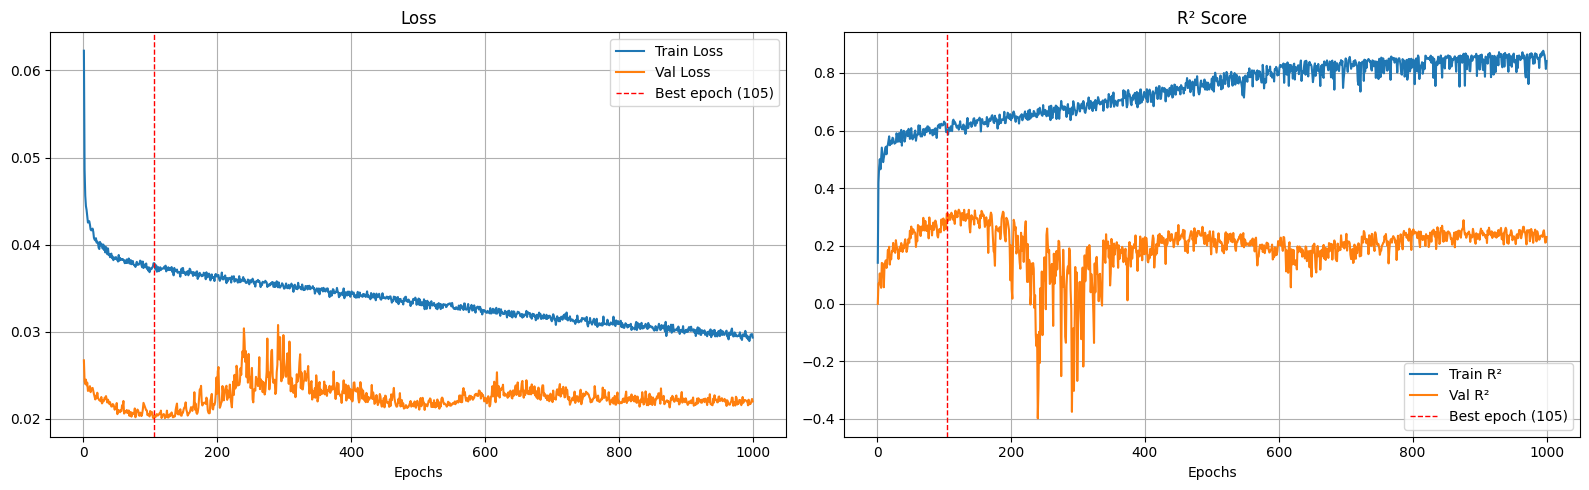

In [7]:
# Training history plots
best_epoch = np.argmin(history.history['val_loss']) + 1
epochs = range(1, len(history.history['loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(epochs, history.history['loss'], label='Train Loss')
ax1.plot(epochs, history.history['val_loss'], label='Val Loss')
ax1.axvline(best_epoch, color='red', linestyle='--', linewidth=1, label=f'Best epoch ({best_epoch})')
ax1.set_title('Loss')
ax1.set_xlabel('Epochs')
ax1.legend()
ax1.grid()

ax2.plot(epochs, history.history['r2_score'], label='Train R²')
ax2.plot(epochs, history.history['val_r2_score'], label='Val R²')
ax2.axvline(best_epoch, color='red', linestyle='--', linewidth=1, label=f'Best epoch ({best_epoch})')
ax2.set_title('R² Score')
ax2.set_xlabel('Epochs')
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()

### 5: Results

In [8]:
# Evaluate on test set
model.load_weights("best_model5O.weights.h5")
loss, r2, mae, rmse = model.evaluate(test_X, test_Y, verbose=0)
print(f"Test Loss (MAE): {loss:.4f} | Test R²: {r2:.4f} | Test RMSE: {rmse:.4f}")

Test Loss (MAE): 0.0296 | Test R²: 0.4898 | Test RMSE: 0.0434


135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


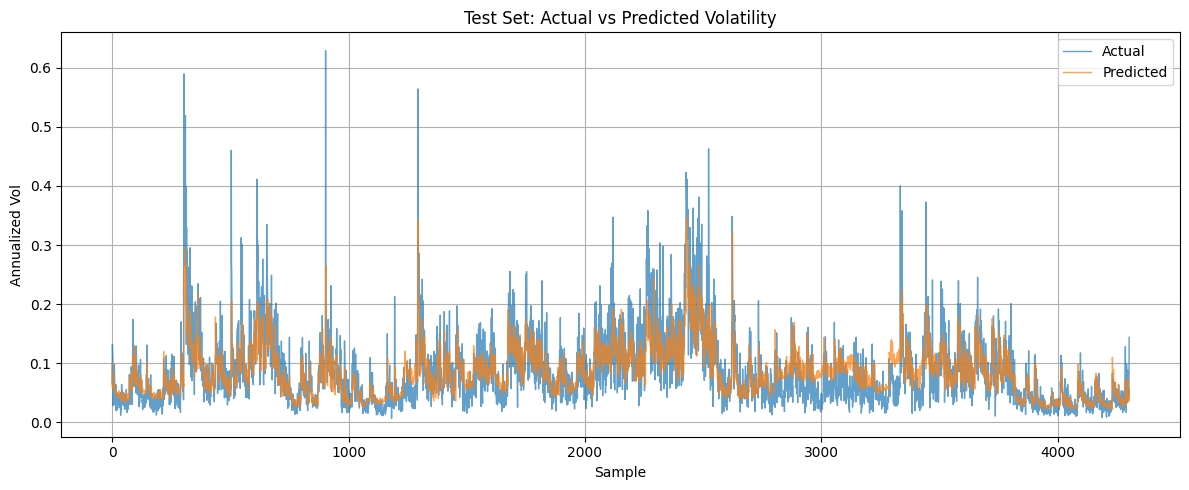

In [54]:
# Plot test predictions vs actual
preds = model.predict(test_X).flatten()
plt.figure(figsize=(12, 5))
plt.plot(test_Y, label='Actual', alpha=0.7, linewidth=1)
plt.plot(preds, label='Predicted', alpha=0.7, linewidth=1)
plt.title('Test Set: Actual vs Predicted Volatility')
plt.xlabel('Sample'); plt.ylabel('Annualized Vol'); plt.legend(); plt.grid(); plt.tight_layout(); plt.show()

In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Baseline predictions: mean of train targets and last observed value from the test series
mean_baseline = np.full_like(test_Y, np.mean(train_Y), dtype=np.float32)
last_baseline = np.concatenate(([test_Y[0]], test_Y[:-1])).astype(np.float32)

mean_mae = mean_absolute_error(test_Y, mean_baseline)
mean_r2 = r2_score(test_Y, mean_baseline)
mean_rmse = np.sqrt(mean_squared_error(test_Y, mean_baseline))
last_mae = mean_absolute_error(test_Y, last_baseline)
last_r2 = r2_score(test_Y, last_baseline)
last_rmse = np.sqrt(mean_squared_error(test_Y, last_baseline))

print(f"Mean baseline MAE: {mean_mae:.4f} | R²: {mean_r2:.4f} | RMSE: {mean_rmse:.4f}")
print(f"Last-value baseline MAE: {last_mae:.4f} | R²: {last_r2:.4f} | RMSE: {last_rmse:.4f}")

Mean baseline MAE: 0.0484 | R²: -0.0550 | RMSE: 0.0624
Last-value baseline MAE: 0.0331 | R²: 0.3399 | RMSE: 0.0494
